## Image Processing for the "Pilot Experiment"
### Jasmine JARDRI - UROP (Soft Matter Science & Engineering team, ESPCI-PSL)

#### Required libraries

In [19]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from scipy.optimize import curve_fit

#### SP profile extraction

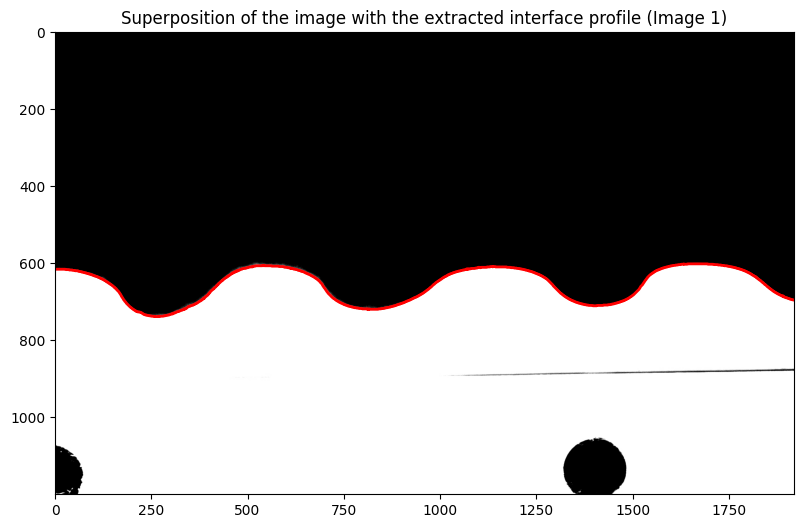

In [23]:
img=imageio.imread("C:\\Users\\jajou\\OneDrive\\Documents\\CPES\\CPES 2\\Stage_UROP\\Experiences\\Exp2026-04-20\\Img_exp_04-20\\Exp_2026_04-20_001.jpg") # replace by the name of the image you want to analyse
if img.ndim == 3:
    img = np.mean(img, axis=2).astype(np.uint8) 


# Binarisation
_, binary = cv2.threshold(img, 200, 255, cv2.THRESH_BINARY) #change the value of 200 to define the black/white transition to another value
height, width = binary.shape 
interface_y = np.zeros(width)

# Interface detection (for each column)
for x in range(width): 
    column = binary[:, x] 
    white_pixels = np.where(column == 255)[0] #search for the white pixels in each column
    interface_y[x] = white_pixels[0] if len(white_pixels) > 0 else np.nan # select the first white pixel from the top (in each column)


# Superposition of the profile on the corresponding image
plt.figure(figsize=(10, 6))
plt.gca().invert_yaxis() 
plt.imshow(img, cmap='gray') 
plt.plot(interface_y, color='red', linewidth=2) 
plt.title(f"Superposition of the image with the extracted interface profile (Image 1)")
plt.show()

#### Example of a sinusoidal fit for one image

Amplitude : 60.05 pixels
Wavelength : 561.49 pixels


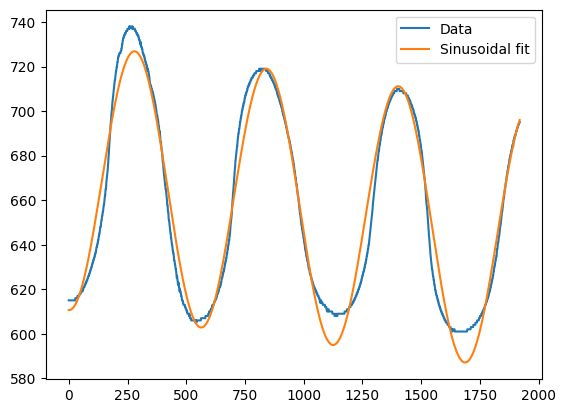

In [ ]:
def sin_model(x, A, T, phi, k, C): 
    return A*np.sin(2 * np.pi * x / T + phi) + k*x + C


x_data = np.arange(len(interface_y))
y_data = interface_y

# Estimation of the parameters in the sin_model function : 
y_detrended = y_data - np.mean(y_data) 
fft = np.fft.fft(y_detrended) 
freqs = np.fft.fftfreq(len(y_data)) 
mask = freqs > 0 
f0 = freqs[mask][np.argmax(np.abs(fft[mask]))]
T0 = 1 / f0


C0 = np.mean(y_data)
k0=1
phi0 = 0

p0 = [A0, T0, phi0, k0, C0]


# Sinusoidal Fit : 
popt, pcov = curve_fit(sin_model, x_data, y_data, p0)
A_fit, T_fit, phi_fit, k_fit, C_fit = popt

print(f"Amplitude : {abs(A_fit):.2f} pixels")
print(f"Wavelength : {abs(T_fit):.2f} pixels")

# Plot : 
plt.plot(x_data, y_data, label='Data')
plt.plot(x_data, sin_model(x_data, *popt), label=f"Sinusoidal fit")
plt.legend()
plt.show()

#### Extraction of the profiles of a whole stack and creation of the list of amplitudes
NB : regarding the evolution of the wavelength during an experiment (for a stack of images), the same script can be used by simply replacing A.append(abs(A_fit)) by T.append(abs(T_fit)) in the amplitude_STACK() function. 

C:\Users\jajou\AppData\Local\Temp\ipykernel_29396\1231988359.py:61: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(sin_model, x_data, y_data, p0) #popt contient les valeurs des paramètres de la fonction modèle proche de notre courbe expérimentale


 
Characteristic time tau : 29.66 min
Offset : 46.64 pixels


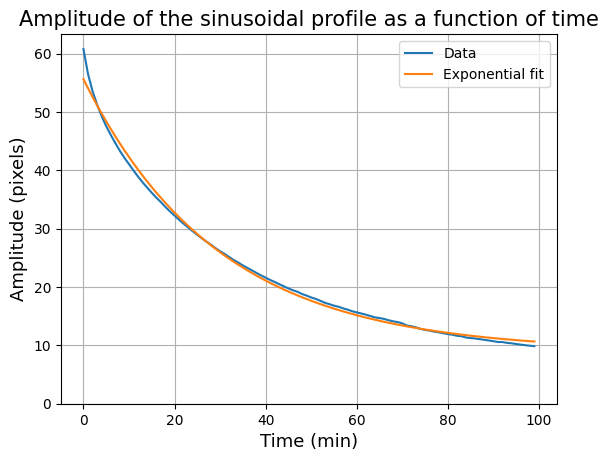

In [ ]:
# Automatisation of the extraction to the whole stack : 
def extract_interface(path, threshold=200) : 
    img=imageio.imread(path) 
    if img.ndim == 3:
        img = np.mean(img, axis=2).astype(np.uint8) 

    _, binary = cv2.threshold(img, threshold, 255, cv2.THRESH_BINARY)

    height, width = binary.shape 
    interface_y = np.zeros(width)

    for x in range(width): 
        column = binary[:, x] 
        white_pixels = np.where(column == 255)[0] 
        interface_y[x] = white_pixels[0] if len(white_pixels) > 0 else np.nan 
    return interface_y


def interface_STACK(basepath, prefixe, nb_images, k) : 
    # returns the list of interface positions for each image (i.e. interfaces[i] corresopnds to the interface for the image n°i

    interfaces=[] 
    for i in range(1,nb_images+1): 
        filename=f"{prefixe}{i:0{k}d}.jpg"   # Pad i with zeros on the left to make a k-digit number
        path=base_path + "\\" + filename
        interface=extract_interface(path)
        interfaces.append(interface)
    return interfaces

def sin_model(x, A, T, phi, k, C): 
    return A*np.sin(2 * np.pi * x / T + phi) + C



def amplitude_STACK(basepath, prefixe, nb_images,k) :  
    # returns the list of amplitude for a stack of images (i.e A[i] is a number corresponding to the amplitude of the profile of image n°i)
    A=[]
    interfaces = interface_STACK(basepath, prefixe, nb_images,k)
    for i in range(nb_images): 
        x_data = np.arange(len(interfaces[i]))  
        y_data = interfaces[i]  


        A0 = (y_data.max() - y_data.min()) / 2
        C0 = np.mean(y_data)
        phi0 = 0
        k0=1

        #Estimation of T0 with FFT (Fast Fourier Transform) : 
        y_detrended = y_data - np.mean(y_data)
        fft = np.fft.fft(y_detrended)
        freqs = np.fft.fftfreq(len(y_data)) 

        mask = freqs > 0
        f0 = freqs[mask][np.argmax(np.abs(fft[mask]))] 
        T0 = 1 / f0

        if i == 0:
            p0 = [A0, T0, phi0, k0, C0]
        else:
            p0 = popt_prec

        popt, pcov = curve_fit(sin_model, x_data, y_data, p0)
        A_fit, T_fit, phi_fit, k_fit, C_fit = popt
        popt_prec=popt
        A.append(abs(A_fit))
    return A


base_path="C:\\Users\\jajou\\OneDrive\\Documents\\CPES\\CPES 2\\Stage_UROP\\Experiences\\Exp2026-04-20\\Img_exp_04-20" # replace by the path of your stack of images
prefixe="Exp_2026_04-20_" # replace by the prefixe of the images of your stack (for instance here the name of the first image was : Exp_2026_04-20_001)
nb_images = 100 # replace by the number of images in your stack
A=amplitude_STACK(base_path, prefixe, nb_images,3) # replace 3 by another number depending on the number of images in your stack (here, there is 100 images so the images of the stack are numbered using 3 digits)


def exp_model(x, B, tau, D): 
    return B*np.exp(-x/tau) + D

# Parameters to help the fit-function : 
B_0=A[0]
p0_2=[B_0, 1, 1]

x2_data=np.arange(len(A))
y2_data=np.array(A)

# Exponential fit for the amplitude over time : 
popt, pcov = curve_fit(exp_model,x2_data, y2_data, p0_2)
B_fit, tau_fit, D_fit= popt

print(" ")
print(f"Characteristic time tau : {tau_fit:.2f} min") 
print(f"Offset : {B_fit:.2f} pixels")

# Plot : 
fig, ax = plt.subplots()
ax.plot(x2_data,y2_data, label='Data')
ax.plot(x2_data, exp_model(x2_data, *popt), label=f"Exponential fit")
ax.set_title("Amplitude of the sinusoidal profile as a function of time", fontsize = 15)
ax.set_xlabel("Time (min)", fontsize = 13)
ax.set_ylabel("Amplitude (pixels)", fontsize = 13)
ax.grid()
ax.set_ylim(bottom=0)
ax.legend()
plt.show()

#### Method to suppress the "spikes" caused by bright spots
We are simply adapting the functions used earlier to extract the profile and create the list of amplitude. As explained in the report, we are cutting the analysis into multiple segments after "manually" identifying the appropriate height percentage (for each segment) from which we are starting the search for white pixels

C:\Users\jajou\AppData\Local\Temp\ipykernel_29396\221695296.py:74: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(sin_model, x_data, y_data, p0)


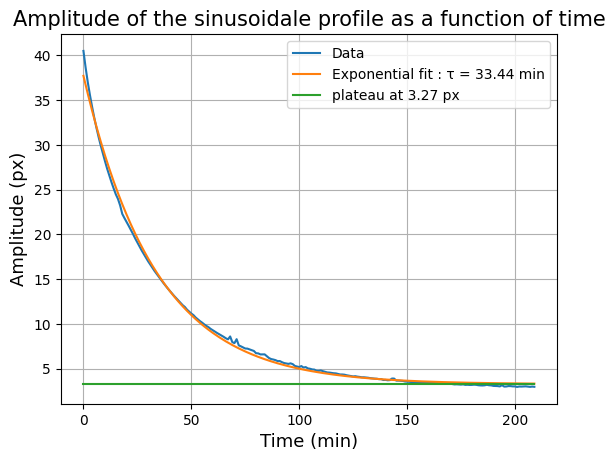

In [ ]:
base_path="C:\\Users\\jajou\\OneDrive\\Documents\\CPES\\CPES 2\\Stage_UROP\\Experiences\\Exp2026-06\\Exp2026-06-05\\Img_exp"
prefixe="Img_exp2026-06-05_" 
nb_images=210
p=0
popt_prec= 0

def extract_interface_2(path,p, threshold=200) : 
    img=imageio.imread(path) 
    if img.ndim == 3:
        img = np.mean(img, axis=2).astype(np.uint8) 

    _, binary = cv2.threshold(img, 200, 255, cv2.THRESH_BINARY)

    height, width = binary.shape 
    interface_y = np.zeros(width)

    for x in range(width): 
        column = binary[:, x] 
        white_pixels = np.where(column == 255)[0] 
        interface_y[x] = white_pixels[0] if len(white_pixels) > 0 else np.nan 



    y_min = int(p * height) 
    # p is the percentage indicating from where starts the search for white pixels (ignoring the white pixels above this height)
    for x in range(width): 
        column = binary[:, x] 
        white_pixels = np.where(column == 255)[0] 
        white_pixels = white_pixels[white_pixels > y_min]
        interface_y[x] = white_pixels[0] if len(white_pixels) > 0 else np.nan

    return interface_y


def interface_STACK_2(basepath, prefixe, nb_images,p) : 
    interfaces=[]

    for i in range(1,nb_images+1): 
        filename=f"{prefixe}{i:03d}.jpg"
        path=base_path + "\\" + filename
        interface=extract_interface_2(path,p)
        interfaces.append(interface)
    return interfaces

def sin_model(x, A, T, phi, k, C): 
    return A*np.sin(2 * np.pi * x / T + phi) + C


def amplitude_STACK_2(basepath, prefixe, nb_images,k,j,p, A, popt_prec) :
    # returns the list of completed amplitudes for an experiment (A[i] = the amplitude of the sine fit for image i)
    interfaces = interface_STACK_2(basepath, prefixe, nb_images,p)
    for i in range(k,j+1): 
        x_data = np.arange(len(interfaces[i]))  
        y_data = interfaces[i]  


        A0 = (y_data.max() - y_data.min()) / 2
        C0 = np.mean(y_data)
        phi0 = 0
        k0=1
 
        y_detrended = y_data - np.mean(y_data)
        fft = np.fft.fft(y_detrended)
        freqs = np.fft.fftfreq(len(y_data)) 

        mask = freqs > 0
        f0 = freqs[mask][np.argmax(np.abs(fft[mask]))] 
        T0 = 1 / f0


        if i == 0:
            p0 = [A0, T0, phi0, k0, C0]
        else:
            p0 = popt_prec

        popt, pcov = curve_fit(sin_model, x_data, y_data, p0) 
        A_fit, T_fit, phi_fit, k_fit, C_fit = popt
        popt_prec = popt
        A.append(abs(A_fit))
    return A, popt_prec


# For the parameters of  amlplitude_STACK_2(), analyse "manually" the stack of images by changing the percentage and decide how to divide the analysis : 
A=[]
A, popt_prec = amplitude_STACK_2(base_path, prefixe, 210, 0, 17,0, A, popt_prec) #interfaces[0] = image 1, interface[17] = image 18 : for these images, the analysis starts from the top of the image
A, popt_prec = amplitude_STACK_2(base_path, prefixe, 210, 18, 85 , 0.29, A, popt_prec) #interfaces[18] = image 1, interface[85] = image 86 : for these images, the analysis starts only at 0.29% of the image height (from the top)
A, popt_prec = amplitude_STACK_2(base_path, prefixe, 210, 86, 209 , 0.30, A, popt_prec) #interfaces[86] = image 87, interface[209] = image 210  for these images, the analysis starts only at 0.30% of the image height (from the top)

def exp_model(x, B, tau, D): 
    return B*np.exp(-x/tau) + D


B_0=A[0]
p0_2=[B_0, 1, 1]

x2_data=np.arange(len(A))
y2_data=np.array(A)
popt, pcov = curve_fit(exp_model,x2_data, y2_data, p0_2)
B_fit, tau_fit, D_fit= popt


# Plot : 
fig, ax = plt.subplots()
ax.plot(x2_data,y2_data, label='Data')
ax.plot(x2_data,exp_model(x2_data, *popt), label=f'Exponential fit : τ = {tau_fit:.2f} min')
ax.plot(x2_data, [D_fit]*len(x2_data), label = f"plateau at {D_fit:.2f} px")
ax.set_title("Amplitude of the sinusoidale profile as a function of time", fontsize = 15)
ax.set_xlabel("Time (min)", fontsize = 13)
ax.set_ylabel("Amplitude (px)", fontsize = 13)
ax.grid()
#ax.set_ylim(bottom=0)
ax.legend()
plt.show()